# Time Series Data Analysis
## Lab 7 — Stock Market Data

### Aim
To analyze and visualize stock-price data using simple time-series techniques.

### Dataset note
`sklearn.datasets` does not provide a stock-market dataset. Therefore, the **Diabetes dataset from sklearn** is used as the base data, and a simple stock-style dataset with **Date, Closing Price, and Volume** is created from it.

### Tasks
1. Load and explore the dataset.
2. Convert the date column to datetime.
3. Plot stock-price trends.
4. Calculate a moving average.
5. Perform simple seasonal analysis.
6. Analyze correlation with trading volume.
7. Forecast future prices using exponential smoothing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option("display.max_columns", None)


## 1. Create the stock-price dataset using sklearn

In [2]:
# Load a dataset from sklearn
diabetes = load_diabetes(as_frame=True)

base = diabetes.frame.copy()

# Use the target values as the base for a simple stock-price series
np.random.seed(42)

price_base = (
    (base["target"] - base["target"].min()) /
    (base["target"].max() - base["target"].min())
)

# Create a simple stock-style closing price
closing_price = 100 + price_base * 80 + np.arange(len(base)) * 0.08
closing_price = closing_price + np.random.normal(0, 2, len(base))

# Create trading volume
volume = np.random.randint(1000, 10000, len(base))

df = pd.DataFrame({
    "Date": pd.date_range("2025-01-01", periods=len(base), freq="D"),
    "Closing_Price": np.round(closing_price, 2),
    "Volume": volume
})

# Save as CSV
df.to_csv("Stock_Prices.csv", index=False)

print("Dataset created successfully.")
display(df.head())


Dataset created successfully.


,Date,Closing_Price,Volume
0,2025-01-01,132.40,6569
1,2025-01-02,112.26,5300
2,2025-01-03,130.37,7269
3,2025-01-04,148.40,4818
4,2025-01-05,127.27,2906


## 2. Explore the dataset

In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())


Dataset shape: (442, 3)

Column names:
['Date', 'Closing_Price', 'Volume']

Data types:
Date             datetime64[us]
Closing_Price           float64
Volume                    int32
dtype: object

Basic statistics:


,Date,Closing_Price,Volume
count,442,442.000000,442.000000
mean,2025-08-09 12:00:00,149.376697,5546.314480
min,2025-01-01 00:00:00,106.930000,1005.000000
25%,2025-04-21 06:00:00,131.725000,3376.500000
50%,2025-08-09 12:00:00,145.495000,5507.500000
75%,2025-11-27 18:00:00,167.430000,7697.250000
max,2026-03-18 00:00:00,207.380000,9996.000000
std,NaN,22.464546,2535.959446


## 3. Convert Date column to datetime

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as the index for time-series analysis
df = df.set_index("Date")

print(df.dtypes)
display(df.head())


Closing_Price    float64
Volume             int32
dtype: object


,Closing_Price,Volume
Date,,
2025-01-01,132.40,6569
2025-01-02,112.26,5300
2025-01-03,130.37,7269
2025-01-04,148.40,4818
2025-01-05,127.27,2906


## 4. Plot historical stock-price trend

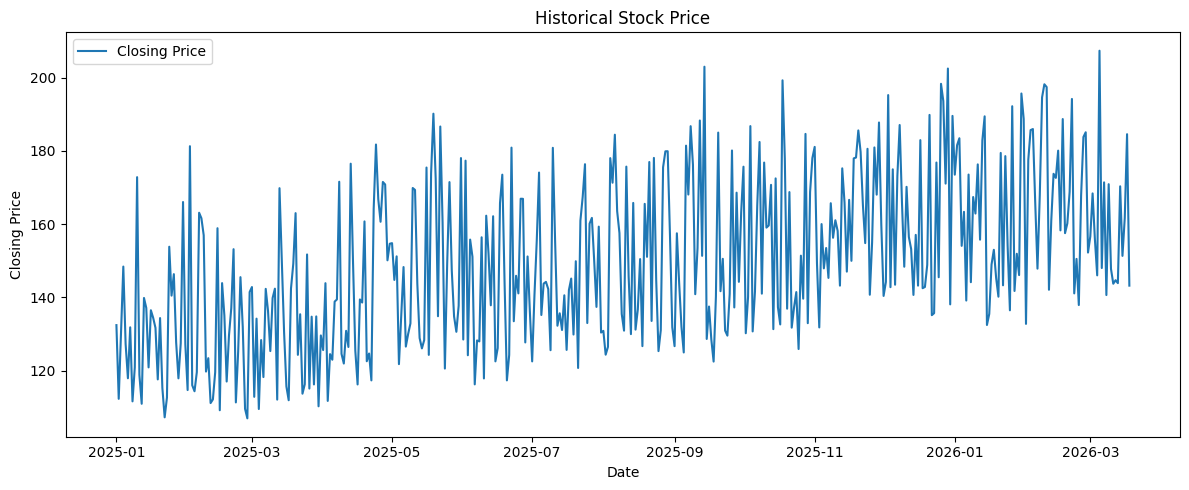

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["Closing_Price"], label="Closing Price")

plt.title("Historical Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Calculate and plot moving average

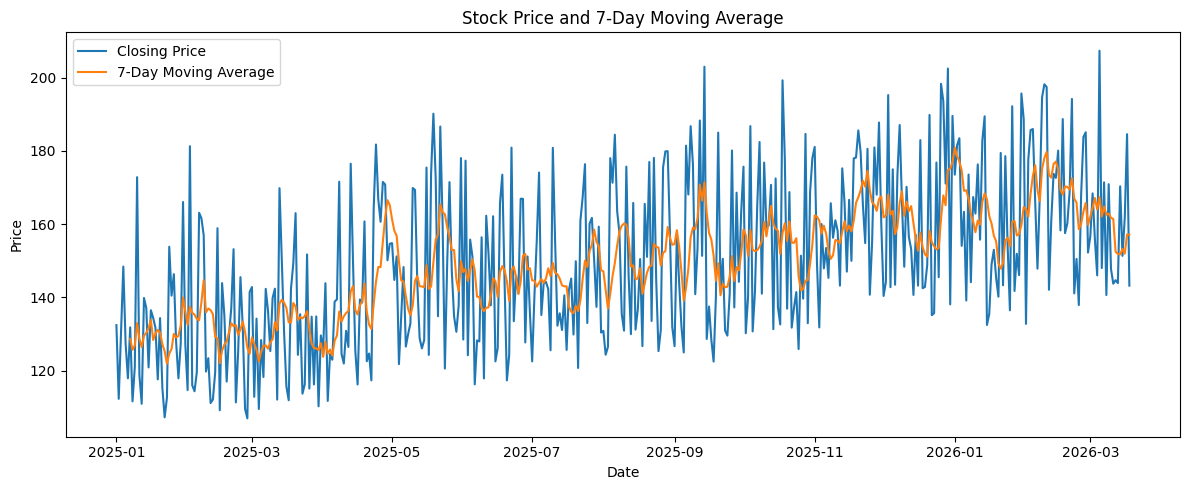

In [6]:
# Calculate a 7-day moving average
df["Moving_Average_7"] = df["Closing_Price"].rolling(window=7).mean()

plt.figure(figsize=(12, 5))

plt.plot(df.index, df["Closing_Price"], label="Closing Price")
plt.plot(df.index, df["Moving_Average_7"], label="7-Day Moving Average")

plt.title("Stock Price and 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Simple seasonality analysis

Average Closing Price by Month:


Date
1     145.811774
2     149.974286
3     141.105306
4     142.455000
5     148.360968
6     144.027667
7     145.446452
8     151.465161
9     152.118333
10    155.094194
11    162.414000
12    162.246129
Name: Closing_Price, dtype: float64

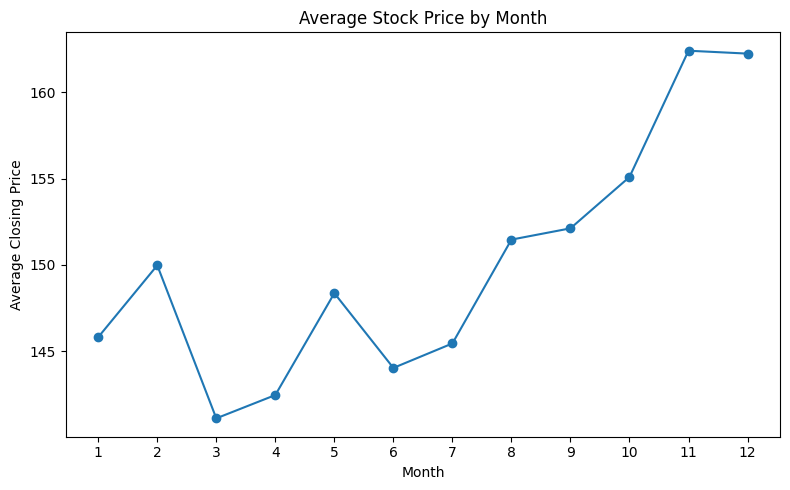

In [7]:
# Calculate average closing price for each month
monthly_average = df.groupby(df.index.month)["Closing_Price"].mean()

print("Average Closing Price by Month:")
display(monthly_average)

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o"
)

plt.title("Average Stock Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


## 7. Correlation between stock price and trading volume

Correlation between Closing Price and Volume: 0.04


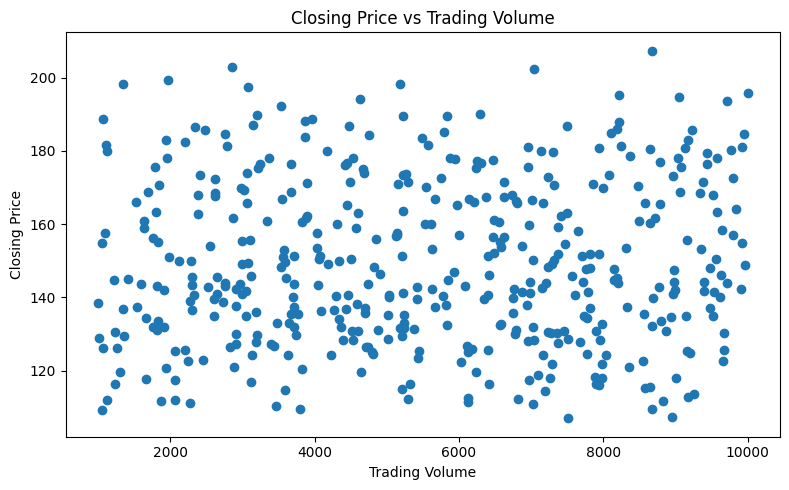

In [8]:
correlation = df["Closing_Price"].corr(df["Volume"])

print(f"Correlation between Closing Price and Volume: {correlation:.2f}")

plt.figure(figsize=(8, 5))

plt.scatter(df["Volume"], df["Closing_Price"])

plt.title("Closing Price vs Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()


## 8. Forecast future stock prices using exponential smoothing

In [9]:
# Use the closing price for forecasting
price_series = df["Closing_Price"]

# Create an exponential smoothing model
model = ExponentialSmoothing(
    price_series,
    trend="add",
    seasonal=None
)

model_fit = model.fit()

# Forecast the next 30 days
forecast = model_fit.forecast(30)

print("Forecasted prices:")
display(forecast.head(10))


Forecasted prices:


d:\Applications\Anaconda\envs\ds\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2026-03-19    169.310705
2026-03-20    169.400701
2026-03-21    169.490696
2026-03-22    169.580692
2026-03-23    169.670687
2026-03-24    169.760683
2026-03-25    169.850678
2026-03-26    169.940674
2026-03-27    170.030669
2026-03-28    170.120665
Freq: D, dtype: float64

## 9. Plot the forecast

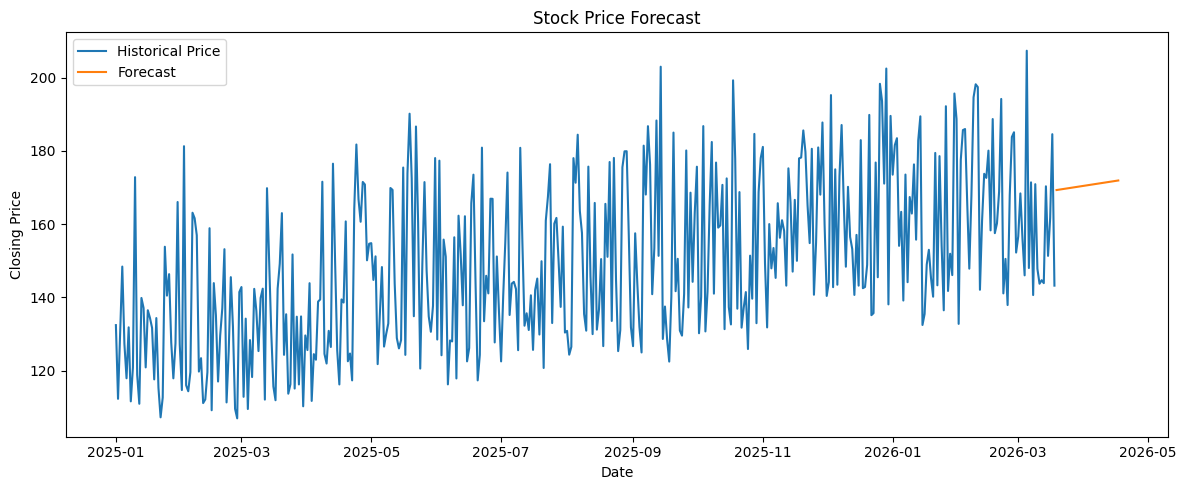

In [10]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30
)

plt.figure(figsize=(12, 5))

plt.plot(
    df.index,
    df["Closing_Price"],
    label="Historical Price"
)

plt.plot(
    future_dates,
    forecast.values,
    label="Forecast"
)

plt.title("Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.tight_layout()
plt.show()


## Conclusion

The stock-style time-series data was analyzed using:

- Date-time conversion
- Line plot for historical prices
- 7-day moving average
- Simple monthly seasonality analysis
- Correlation between price and trading volume
- Exponential smoothing for forecasting future prices

These techniques help identify trends, smooth short-term fluctuations, and make simple future-price forecasts.
